In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns   
df = pd.read_csv("household_power_consumption.txt", sep=";", na_values="?")
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"],dayfirst=True)
df = df.set_index("Datetime")
df = df.drop(columns=['Date', 'Time'])
df = df.interpolate(method='time', limit=10, numeric_only=True)
rows_with_nan = df[df.isnull().any(axis=1)]
#print(rows_with_nan)
#print(df.isnull().sum())
#df.head(100)
#print(df.index.is_monotonic_increasing)


In [45]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049512e+06,2.049512e+06,2.049512e+06,2.049512e+06,2.049512e+06,2.049512e+06,2.049512e+06
mean,1.091633e+00,1.237207e-01,2.408398e+02,4.627842e+00,1.121906e+00,1.298523e+00,6.458383e+00
std,1.057306e+00,1.127278e-01,3.239998e+00,4.444446e+00,6.152979e+00,5.821859e+00,8.437078e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


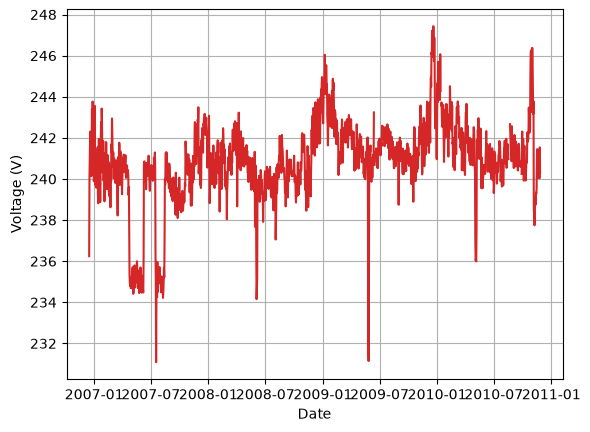

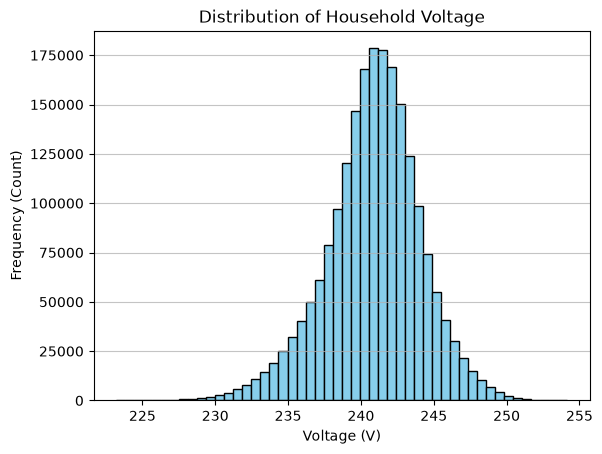

C:\Users\5411\AppData\Local\Temp\ipykernel_29936\2769635090.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Hour'], y=df['Voltage'], palette='vlag', fliersize=1)


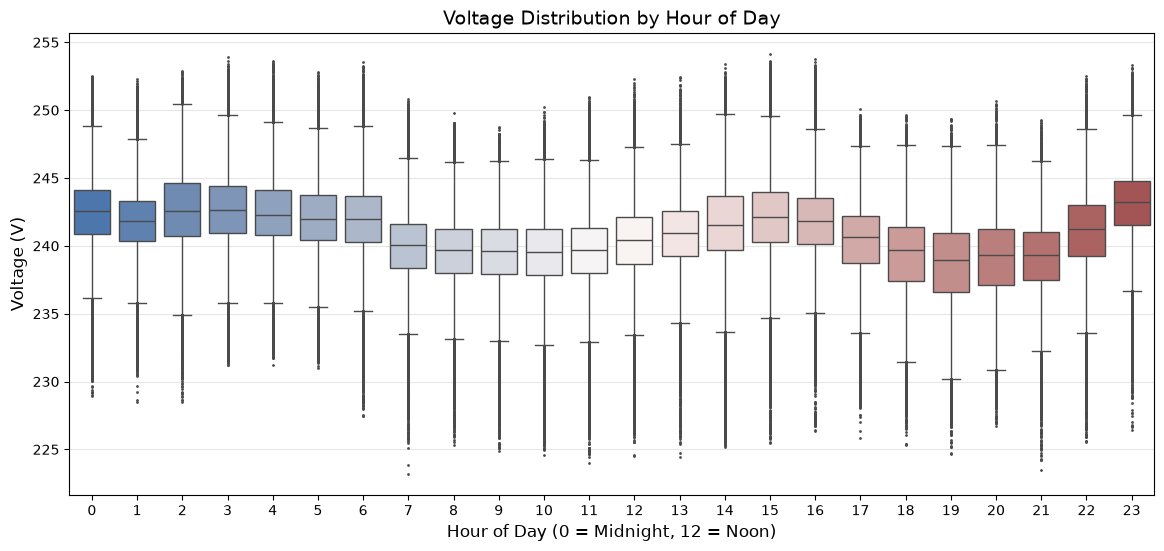

In [46]:
df_daily = df["Voltage"].resample("1D").mean()
plt.plot(df_daily.index, df_daily.values, color="tab:red")
plt.xlabel("Date")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.show()
plt.close()

plt.hist(df['Voltage'], bins=50, color="skyblue", edgecolor="black")

plt.title("Distribution of Household Voltage")
plt.xlabel("Voltage (V)")
plt.ylabel("Frequency (Count)")
plt.grid(axis='y', alpha=0.75)

plt.show()
plt.close()
df['Hour'] = df.index.hour
plt.figure(figsize=(14, 6))
sns.boxplot(x=df['Hour'], y=df['Voltage'], palette='vlag', fliersize=1)
plt.title('Voltage Distribution by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)', fontsize=12)
plt.ylabel('Voltage (V)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [51]:
#Creating Synthetic Frequency
import numpy as np
f_nominal = 50
noise = np.random.normal(0, 0.02, size=(len(df)) )
power_normalized = (df['Global_active_power'] - df['Global_active_power'].mean()) / df['Global_active_power'].std()
load_effect = -0.015 * power_normalized
df['Frequency'] = f_nominal + noise + load_effect
df['Frequency'] = df['Frequency'].round(2)
print(df['Frequency'])

Datetime
2006-12-16 17:24:00    49.96
2006-12-16 17:25:00    49.93
2006-12-16 17:26:00    49.94
2006-12-16 17:27:00    49.94
2006-12-16 17:28:00    49.96
                       ...  
2010-11-26 20:58:00    50.00
2010-11-26 20:59:00    50.03
2010-11-26 21:00:00    50.00
2010-11-26 21:01:00    50.01
2010-11-26 21:02:00    50.00
Name: Frequency, Length: 2075259, dtype: float64


In [ ]:

nominal_voltage_simple = df['Voltage'].round(0).mode()[0]
print(f"Simple Nominal Voltage Check: {nominal_voltage_simple} V")

Datetime
2006-12-16 17:24:00    4.236671
2006-12-16 17:25:00    5.377704
2006-12-16 17:26:00    5.397025
2006-12-16 17:27:00    5.411335
2006-12-16 17:28:00    3.703828
                         ...   
2010-11-26 20:58:00    0.946000
2010-11-26 20:59:00    0.944000
2010-11-26 21:00:00    0.938000
2010-11-26 21:01:00    0.934000
2010-11-26 21:02:00    0.932000
Name: apparent_power, Length: 2075259, dtype: float64
Simple Nominal Voltage Check: 241.0 V


In [ ]:
def train_features(df,voltage_nominal=241,frequency_nominal=50,rolling_window=30,):
    df = df.copy()
    # Apparent Power (VA)
    df["apparent_power"] = np.sqrt(
        df["Global_active_power"]**2 +
        df["Global_reactive_power"]**2
    )

    # Power Factor
    df["power_factor"] = np.where(
        df["apparent_power"] != 0,
        df["Global_active_power"] / df["apparent_power"],
        0
    )

    # Voltage Deviation
    df["voltage_deviation"] = (
        df["Voltage"] - voltage_nominal
    )

    # Frequency Deviation
    df["frequency_deviation"] = (
        df["Frequency"] - frequency_nominal
    )

    df["voltage_mean"] = (
        df["Voltage"]
        .rolling(rolling_window, min_periods=1)
        .mean()
    )

    df["frequency_mean"] = (
        df["Frequency"]
        .rolling(rolling_window, min_periods=1)
        .mean()
    )

    df["current_mean"] = (
        df["Global_intensity"]
        .rolling(rolling_window, min_periods=1)
        .mean()
    )

    df["active_power_mean"] = (
        df["Global_active_power"]
        .rolling(rolling_window, min_periods=1)
        .mean()
    )

    df["reactive_power_mean"] = (
        df["Global_reactive_power"]
        .rolling(rolling_window, min_periods=1)
        .mean()
    )


    df["voltage_std"] = (
        df["Voltage"]
        .rolling(rolling_window, min_periods=1)
        .std()
    )

    df["frequency_std"] = (
        df["Frequency"]
        .rolling(rolling_window, min_periods=1)
        .std()
    )

    df["current_std"] = (
        df["Global_intensity"]
        .rolling(rolling_window, min_periods=1)
        .std()
    )

    df["active_power_std"] = (
        df["Global_active_power"]
        .rolling(rolling_window, min_periods=1)
        .std()
    )

    df["reactive_power_std"] = (
        df["Global_reactive_power"]
        .rolling(rolling_window, min_periods=1)
        .std()
    )


    df["voltage_change"] = df["Voltage"].diff()

    df["frequency_change"] = df["Frequency"].diff()

    df["current_change"] = df["Global_intensity"].diff()

    df["active_power_change"] = (
        df["Global_active_power"].diff()
    )

    df["reactive_power_change"] = (
        df["Global_reactive_power"].diff()
    )


    df["hour"] = df.index.hour

    df["day_of_week"] = (
        df.index.dayofweek
    )

    df["month"] = df.index.month

    df["weekend"] = (
        df["day_of_week"] >= 5
    ).astype(int)
    
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
            
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df.drop(columns=["hour", "day_of_week", "month"], inplace=True)
    return df

In [68]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
new_df = train_features(df)
new_df = new_df.dropna()
new_df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Frequency,apparent_power,power_factor,voltage_deviation,frequency_deviation,voltage_mean,frequency_mean,current_mean,active_power_mean,reactive_power_mean,voltage_std,frequency_std,current_std,active_power_std,reactive_power_std,voltage_change,frequency_change,current_change,active_power_change,reactive_power_change,weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,49.93,5.377704,0.996708,-7.37,-0.07,234.235000,49.945000,20.700000,4.788000,0.427000,0.855599,0.021213,3.252691,0.808930,0.012728,-1.21,-0.03,4.6,1.144,0.018,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,49.94,5.397025,0.995734,-7.71,-0.06,233.920000,49.943333,21.466667,4.983333,0.450667,0.814678,0.015275,2.655811,0.664567,0.041968,-0.34,0.01,0.0,0.014,0.062,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,49.94,5.411335,0.995688,-7.26,-0.06,233.875000,49.942500,21.850000,5.084500,0.463500,0.671243,0.012583,2.300000,0.579113,0.042814,0.45,0.00,0.0,0.014,0.004,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,49.96,3.703828,0.989787,-5.32,-0.04,234.236000,49.946000,20.640000,4.800800,0.476400,0.994751,0.013416,3.359762,0.808676,0.046977,1.94,0.02,-7.2,-1.722,0.026,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0,17,49.96,3.558495,0.989182,-5.98,-0.04,234.366667,49.948333,19.700000,4.587333,0.484000,0.945551,0.013292,3.785763,0.892510,0.045957,-0.66,0.00,-0.8,-0.146,-0.006,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0


In [ ]:
print(pd.__version__)

c:\Users\5411\Desktop\ML\VS TEST\.venv\Scripts\python.exe
